In [85]:
import sys
print(sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

d:\CEIA\ml_env\.venv\Scripts\python.exe


# a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [86]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

train_df= pd.read_csv("adult_train.csv")
val_df= pd.read_csv("adult_val.csv")
print("Dimensiones del dataset:", train_df.shape)
train_df.head()

Dimensiones del dataset: (30162, 14)


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K


## 1. Estructura general del dataset

El dataset contiene **14 columnas**: 4 numéricas (`age`, `capital-gain`, `capital-loss`, `hours-per-week`), 9 categóricas de entrada, y la variable objetivo `income` (también categórica, binaria). 

In [87]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB


In [88]:
# Nulos explícitos (NaN)
nulos = train_df.isna().sum()
print("Valores nulos (NaN) por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos explícitos (NaN) en ninguna columna.")

# Duplicados
print("\nFilas duplicadas:", train_df.duplicated().sum(), f"({train_df.duplicated().mean()*100:.2f}% del total)")

Valores nulos (NaN) por columna:
No hay valores nulos explícitos (NaN) en ninguna columna.

Filas duplicadas: 479 (1.59% del total)


In [89]:
# Elimino duplicados
print("Dimensiones antes de eliminar duplicados:", train_df.shape)
train_df = train_df.drop_duplicates().reset_index(drop=True)
print("Dimensiones tras eliminar duplicados:", train_df.shape)

Dimensiones antes de eliminar duplicados: (30162, 14)
Dimensiones tras eliminar duplicados: (29683, 14)


## 2. Análisis univariado — Variables numéricas

Variables numéricas: `age`, `capital-gain`, `capital-loss`, `hours-per-week`.


In [90]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]
train_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,29683.0,38.546744,13.130225,17.0,28.0,37.0,47.0,90.0
capital-gain,29683.0,1109.629788,7464.558413,0.0,0.0,0.0,0.0,99999.0
capital-loss,29683.0,89.798572,407.390396,0.0,0.0,0.0,0.0,4356.0
hours-per-week,29683.0,40.991645,12.015810,1.0,40.0,40.0,45.0,99.0


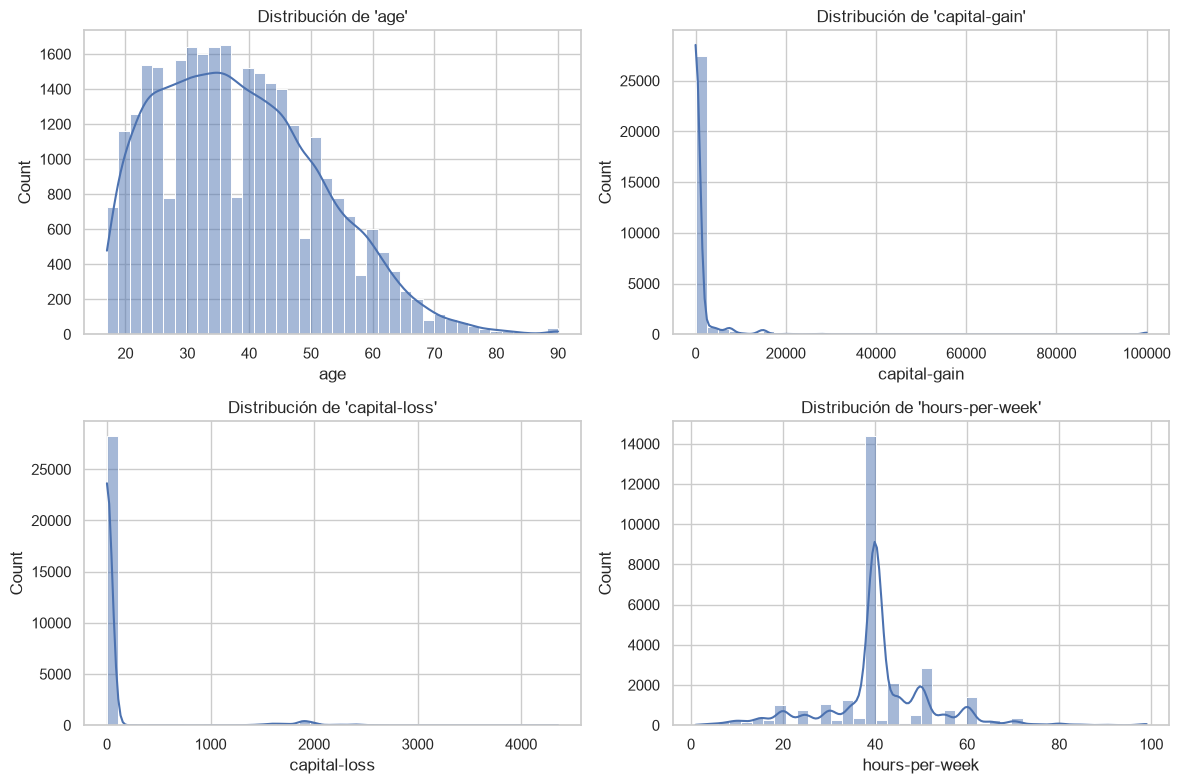

In [91]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train_df[col], bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribución de '{col}'")
plt.tight_layout()
plt.show()

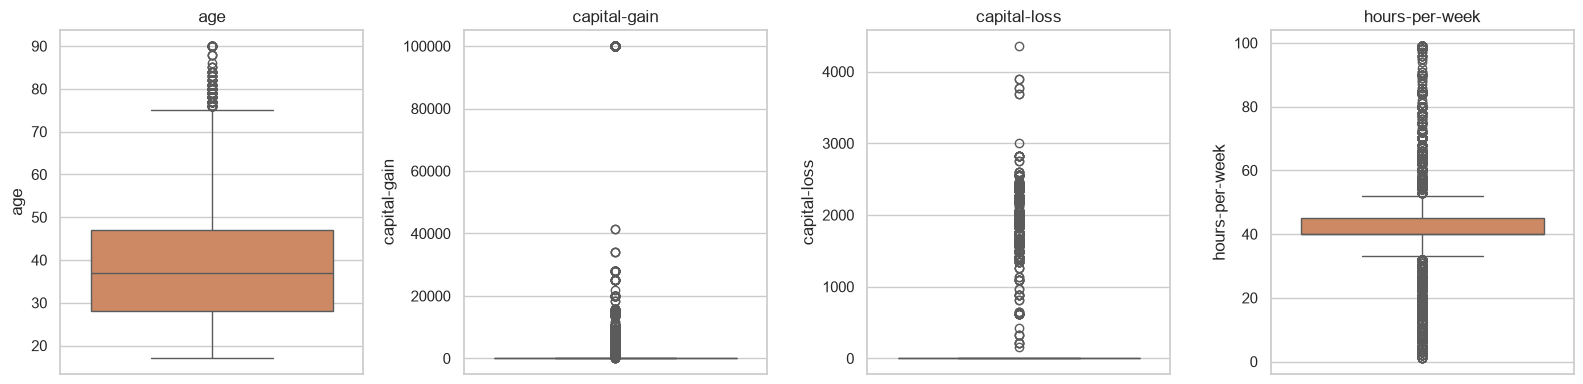

In [92]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=train_df[col], ax=ax, color="#DD8452")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Análisis univariado — Variables categóricas y cardinalidad

Se listan aquí **todas** las variables categóricas del dataset, su número de categorías únicas (cardinalidad) y su distribución de frecuencias.


In [93]:
cat_cols = ["workclass", "education", "marital-status", "occupation",
            "relationship", "race", "sex", "skill-profile",
            "native-country", "income"]

cardinalidad = pd.DataFrame({
    "n_categorias": [train_df[c].nunique() for c in cat_cols],
    "categoria_mas_frecuente": [train_df[c].mode()[0] for c in cat_cols],
    "pct_categoria_mas_frecuente": [round(train_df[c].value_counts(normalize=True).iloc[0]*100, 1) for c in cat_cols],
    "alta_cardinalidad": [train_df[c].nunique() > 10 for c in cat_cols]
}, index=cat_cols).sort_values("n_categorias")

cardinalidad

,n_categorias,categoria_mas_frecuente,pct_categoria_mas_frecuente,alta_cardinalidad
sex,2,Male,67.5,False
income,2,<=50K,74.9,False
race,5,White,85.8,False
relationship,6,Husband,41.2,False
marital-status,7,Married-civ-spouse,46.6,False
workclass,7,Private,73.5,False
occupation,14,Prof-specialty,13.6,True
education,16,HS-grad,32.2,True
native-country,41,United-States,91.0,True
skill-profile,80,customer_service_retail,8.9,True


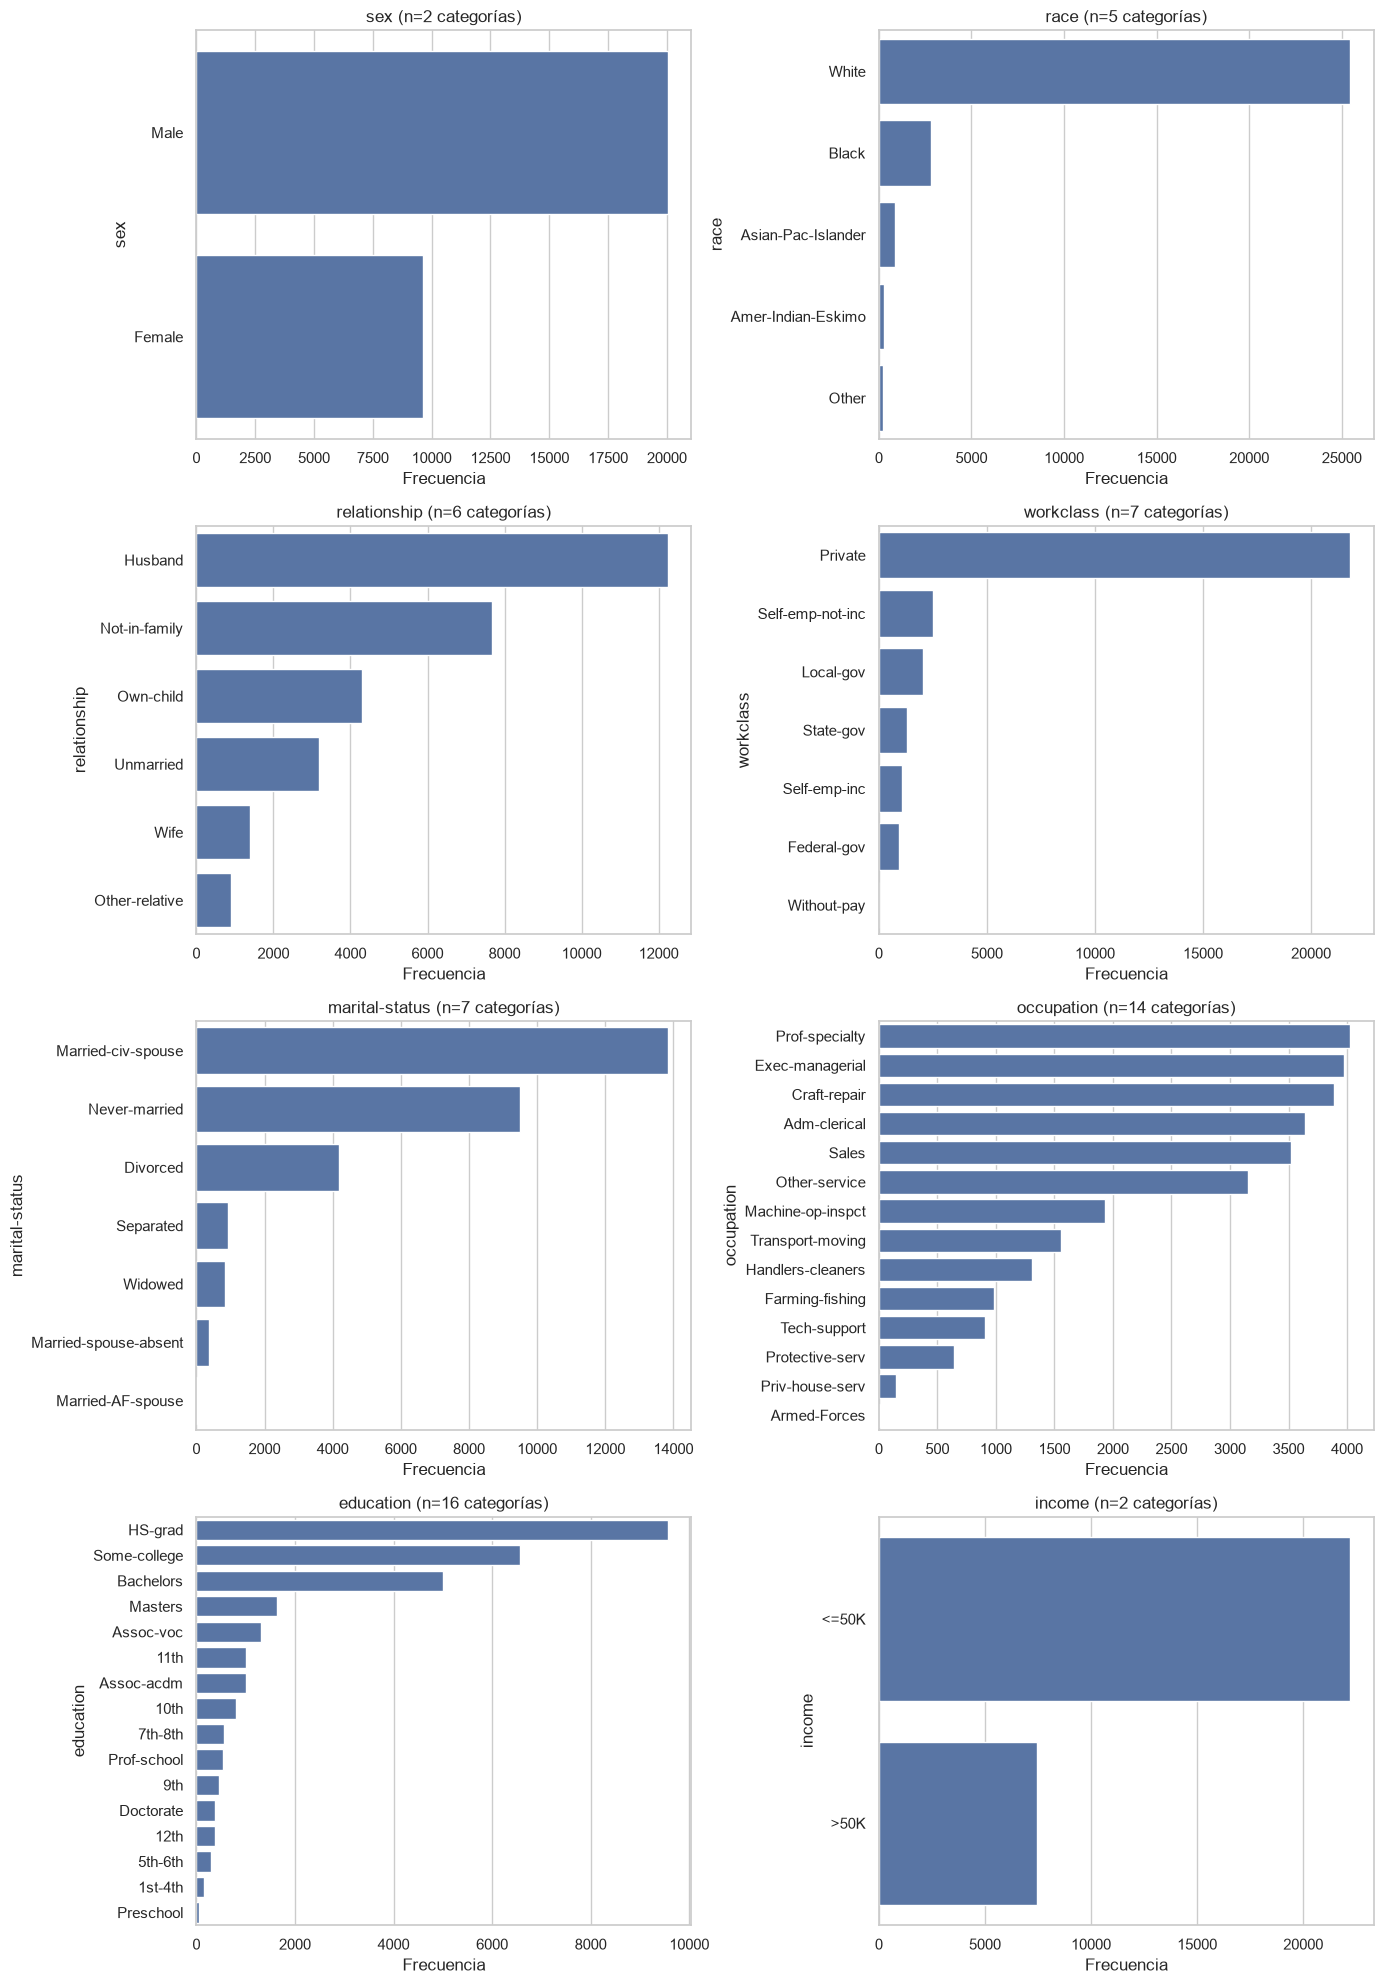

In [94]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
low_med_cols = ["sex", "race", "relationship", "workclass",
                "marital-status", "occupation", "education", "income"]
for ax, col in zip(axes.flatten(), low_med_cols):
    order = train_df[col].value_counts().index
    sns.countplot(y=train_df[col], order=order, ax=ax, color="#4C72B0")
    ax.set_title(f"{col} (n={train_df[col].nunique()} categorías)")
    ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()


**Interpretación:**
- **`age`**: distribución asimétrica a la derecha, concentrada entre 25 y 50 años (mediana ≈ 37), con un límite razonable (17–90). No hay valores imposibles.
- **`capital-gain`** y **`capital-loss`**: son variables **altamente dispersas y con exceso de ceros** (~91.6% y ~95.3% de los registros son 0, respectivamente). Cuando son distintos de cero, toman valores muy grandes (hasta 99 999 en `capital-gain`), lo que genera outliers extremos visibles en el boxplot. Son variables económicas típicas de "cola pesada"; para modelos lineales conviene evaluar una transformación logarítmica (`log1p`) o binarizarlas ("¿tuvo ganancia/pérdida de capital, sí/no?"), aunque para modelos basados en árboles no es estrictamente necesario.
- **`hours-per-week`**: distribución centrada fuertemente en 40 horas (jornada estándar), con colas hacia jornadas parciales y extendidas.

Estas cuatro variables numéricas **no requieren ninguna codificación categórica**; a lo sumo se beneficiarán de un escalado (`StandardScaler`/`MinMaxScaler`) si el modelo lo requiere (p. ej. redes neuronales o modelos basados en distancia).

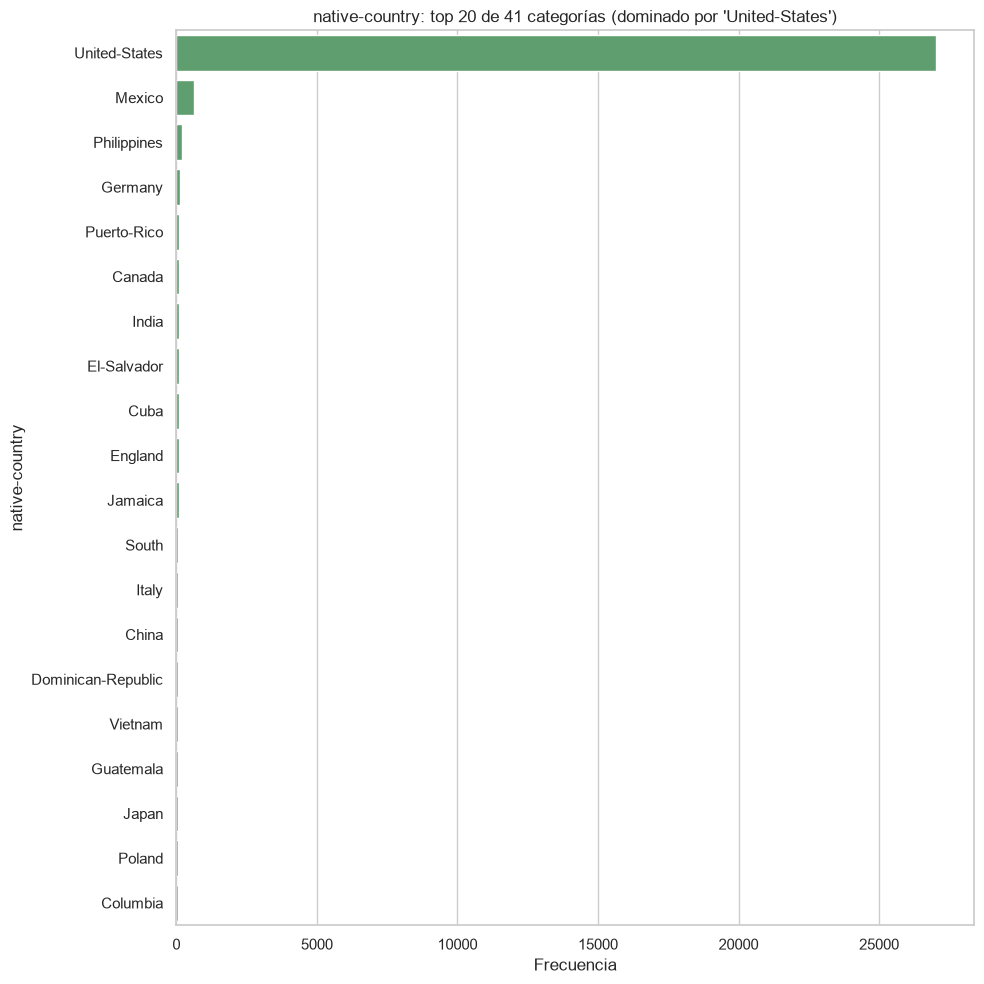

'United-States' representa el 91.0% de los registros.


In [95]:
fig, ax = plt.subplots(figsize=(10, 10))
top20 = train_df["native-country"].value_counts().head(20)
sns.barplot(x=top20.values, y=top20.index, ax=ax, color="#55A868")
ax.set_title("native-country: top 20 de 41 categorías (dominado por 'United-States')")
ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"'United-States' representa el {train_df['native-country'].value_counts(normalize=True).iloc[0]*100:.1f}% de los registros.")

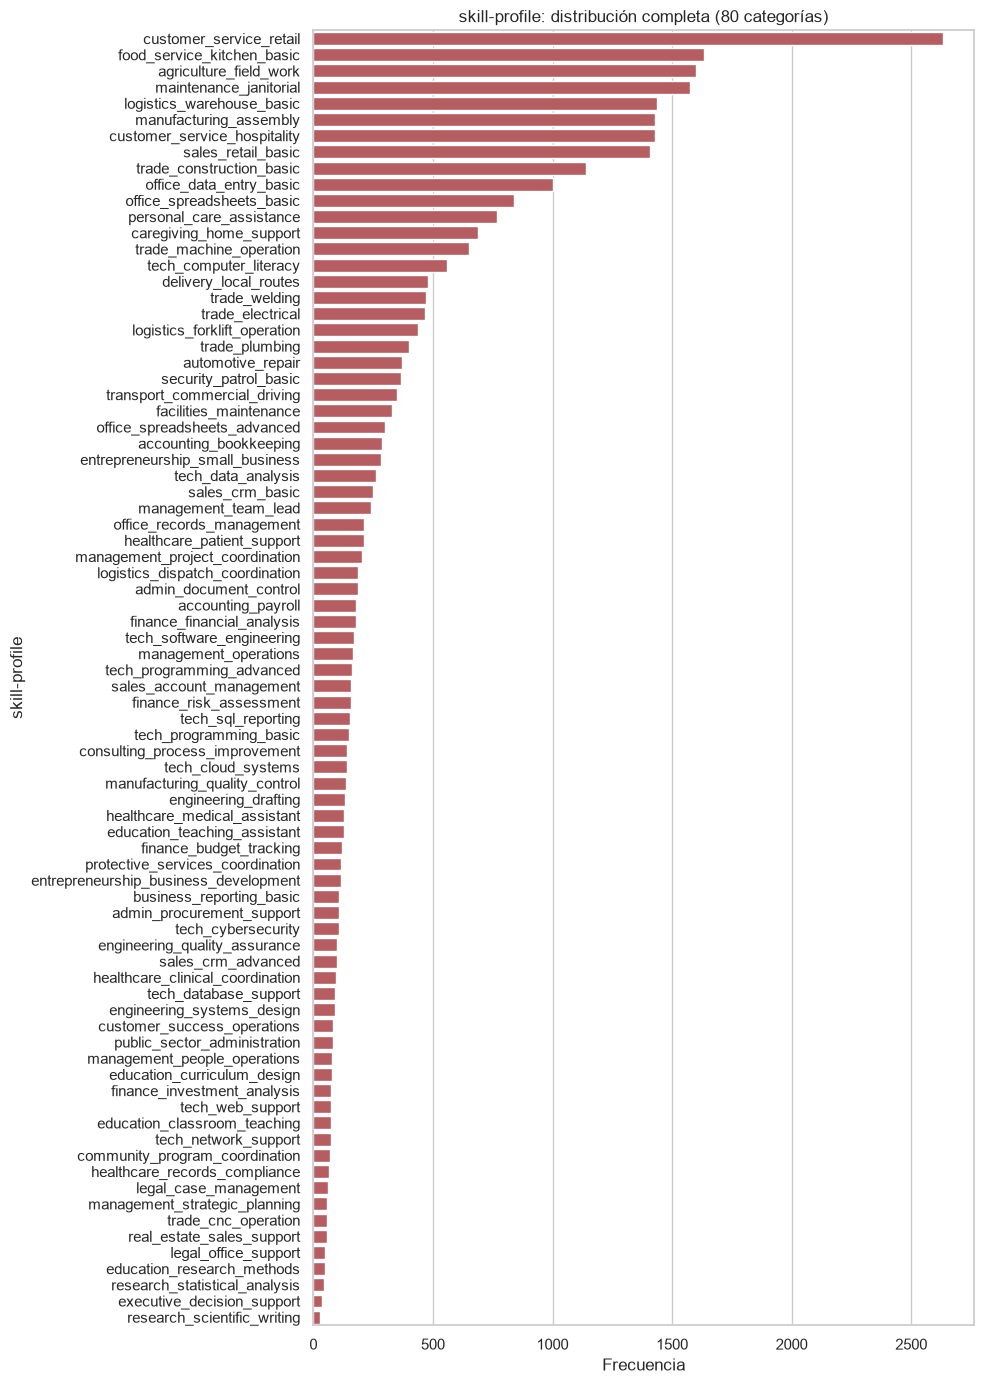

In [96]:
fig, ax = plt.subplots(figsize=(10, 14))
sp = train_df["skill-profile"].value_counts()
sns.barplot(x=sp.values, y=sp.index, ax=ax, color="#C44E52")
ax.set_title(f"skill-profile: distribución completa ({train_df['skill-profile'].nunique()} categorías)")
ax.set_xlabel("Frecuencia")
plt.tight_layout()
plt.show()


**Interpretación de cardinalidad:**
- `sex`, `income`: binarias, sin desbalance estructural relevante en `sex`; `income` sí está desbalanceada (~75% `<=50K` vs ~25% `>50K` — se detalla en la sección bivariada).
- `race`, `relationship`, `workclass`, `marital-status`: cardinalidad baja (5–7) pero **con categorías muy desbalanceadas** (p. ej. `workclass` está dominada por `Private` ~74%, y `race` por `White`).
- `occupation`, `education`: cardinalidad alta (14–16), sin una categoría dominante extrema; en el caso de `education` existe un **orden lógico intrínseco** (nivel educativo creciente).
- `native-country`: 41 categorías, **fuertemente dominada por `United-States` (~91%)**; el resto son categorías muy escasas (algunas con 1–2 observaciones), lo que la convierte en una variable de alta cardinalidad con **desbalanceada**.
- `skill-profile`: 80 categorías con una distribución mucho más repartida (desde ~2 700 hasta ~26 observaciones por categoría), sin dominancia de una sola clase, pero con demasiadas categorías para one-hot sin penalizar la dimensionalidad.

## 4. Análisis bivariado respecto a la variable objetivo (`income`)

Se analiza cómo se relaciona cada variable con la probabilidad de pertenecer a la clase `>50K`.


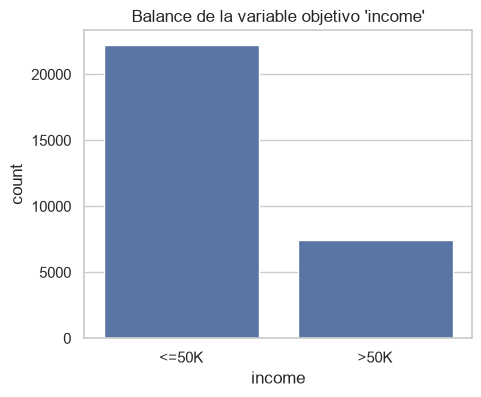

income
<=50K    0.749
>50K     0.251
Name: proportion, dtype: float64


In [97]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="income", data=train_df, color="#4C72B0", ax=ax)
ax.set_title("Balance de la variable objetivo 'income'")
plt.show()

print(train_df["income"].value_counts(normalize=True).round(3))


C:\Users\manud\AppData\Local\Temp\ipykernel_21864\872821683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="income", y=col, data=train_df, ax=ax, palette=["#4C72B0", "#DD8452"])
C:\Users\manud\AppData\Local\Temp\ipykernel_21864\872821683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="income", y=col, data=train_df, ax=ax, palette=["#4C72B0", "#DD8452"])
C:\Users\manud\AppData\Local\Temp\ipykernel_21864\872821683.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="income", y=col, data=train_df, ax=ax, palette=["#4C72B0", "#DD

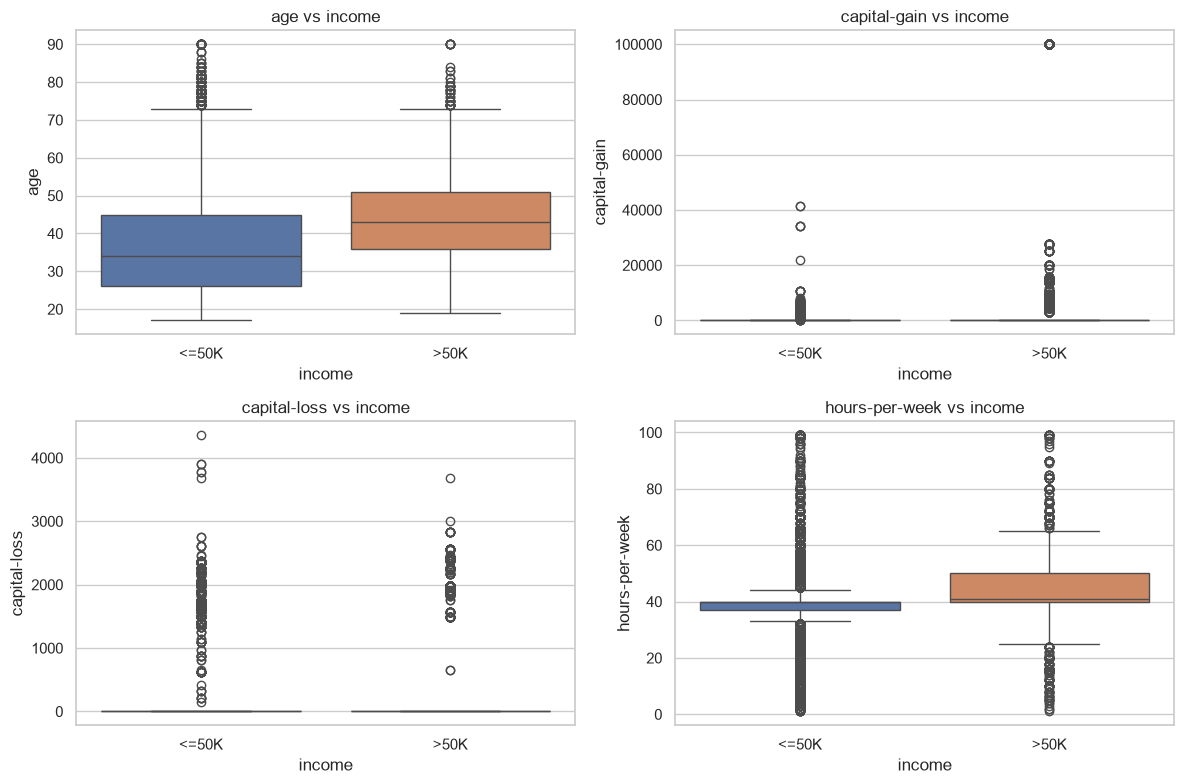

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x="income", y=col, data=train_df, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} vs income")
plt.tight_layout()
plt.show()


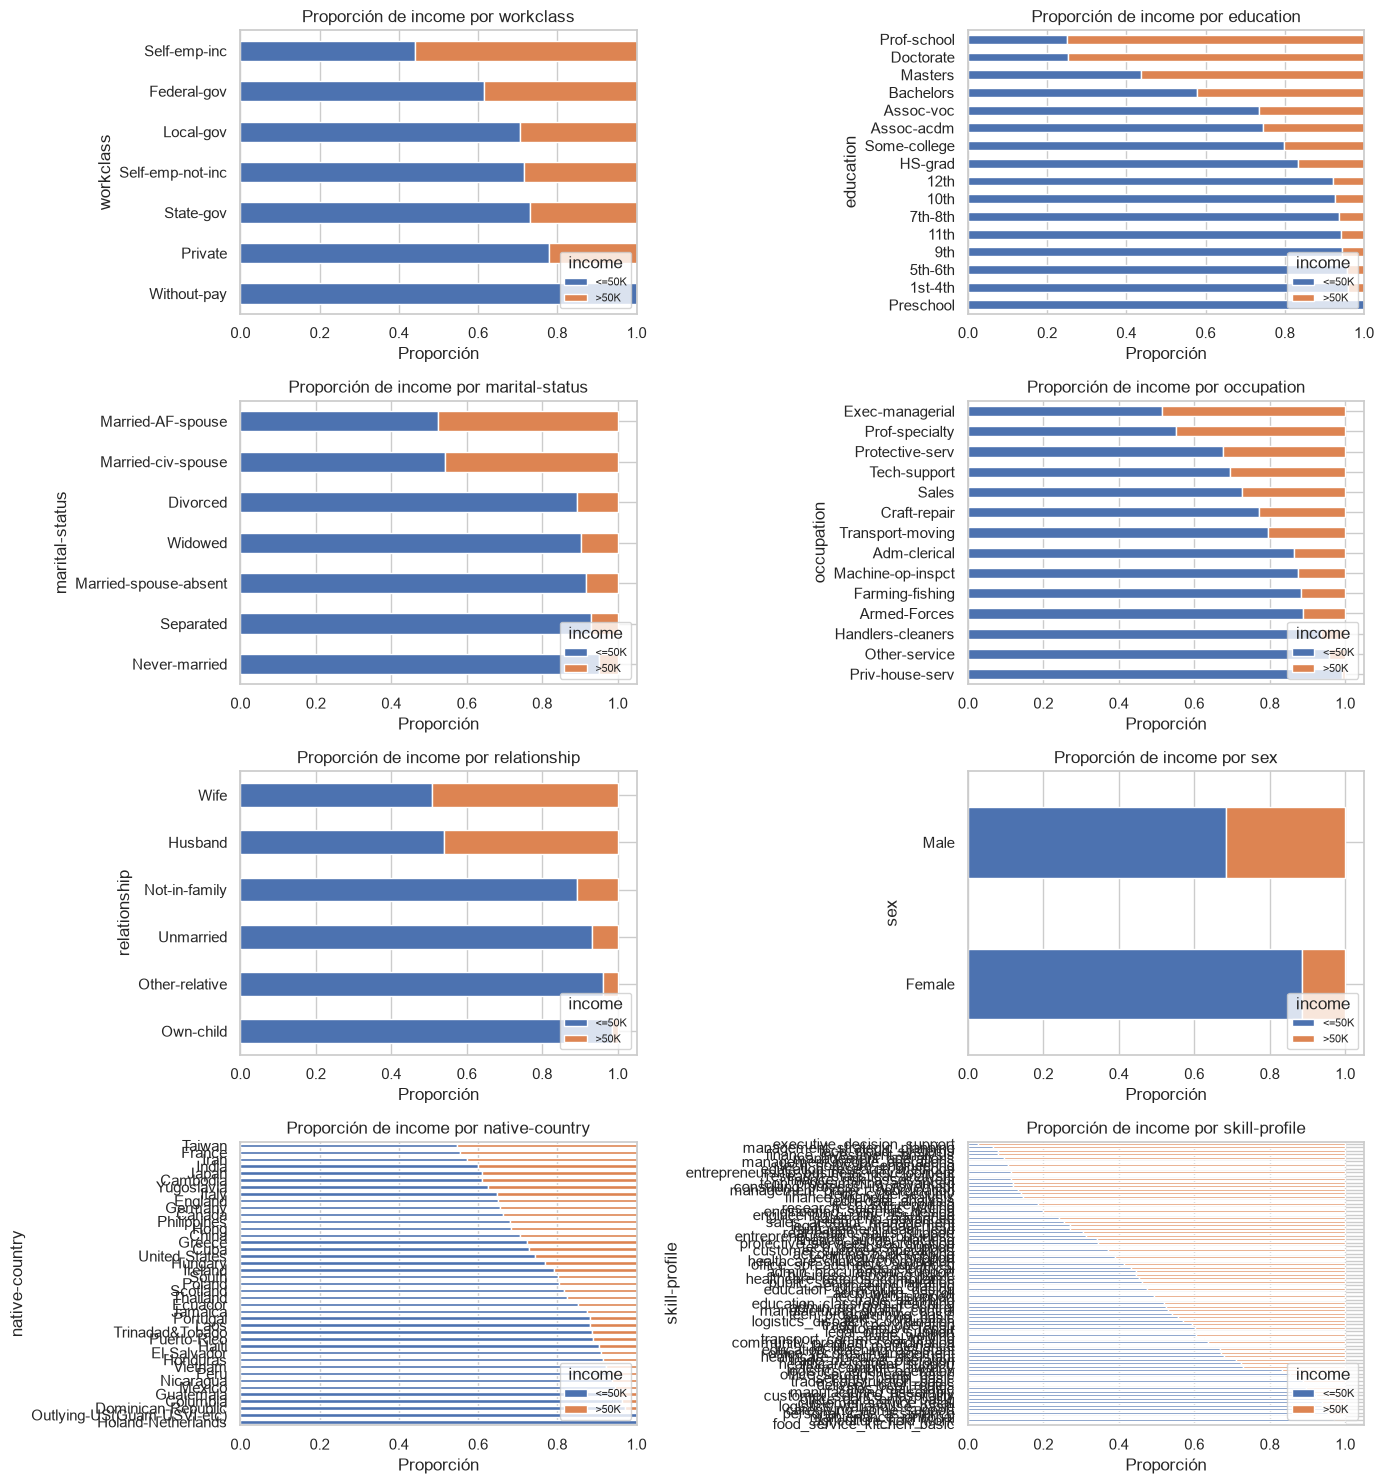

In [99]:
fig, axes = plt.subplots(4, 2, figsize=(14, 15))
cols_biv = ["workclass", "education", "marital-status", "occupation", "relationship", "sex", "native-country", "skill-profile"]
for ax, col in zip(axes.flatten(), cols_biv):
    tab = pd.crosstab(train_df[col], train_df["income"], normalize="index").sort_values(">50K")
    tab.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(f"Proporción de income por {col}")
    ax.set_xlabel("Proporción")
    ax.legend(title="income", loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


**Interpretación:**
- `age`, `hours-per-week` y `capital-gain` muestran una relación clara con `income`: las personas con ingresos `>50K` tienden a ser mayores, trabajar más horas y tener ganancias de capital más frecuentes/altas.
- `education` muestra un **gradiente claro y ordenado**: a mayor nivel educativo, mayor proporción de `>50K` (de `Preschool`/`1st-4th` casi 0% hasta `Doctorate`/`Prof-school` con una proporción mucho más alta). Esto **confirma el orden lógico** de la variable y refuerza la decisión de usar codificación ordinal.
- `marital-status` y `relationship` están fuertemente asociadas al ingreso (p. ej. `Married-civ-spouse`/`Husband`/`Wife` concentran una proporción notablemente mayor de `>50K`), pero **sin un orden lógico entre categorías** (no tiene sentido decir que "Divorced" es "mayor o menor" que "Never-married").
- `workclass` y `occupation` también muestran diferencias relevantes (p. ej. `Self-emp-inc` y `Exec-managerial`/`Prof-specialty` tienen mayor proporción de ingresos altos), igualmente sin orden natural.
- `sex` muestra una diferencia notable en la proporción de `>50K` entre hombres y mujeres, reflejo de un sesgo social presente en los datos históricos (relevante para discusión ética del modelo, no para la codificación en sí).

## 5. Resumen de cardinalidad y decisión final de codificación por variable

La estrategia de codificación se decide combinando dos criterios:

1. **Cardinalidad** (número de categorías únicas).
2. **Existencia de un orden lógico interno** (variable ordinal vs. nominal).


| Variable | Cardinalidad | ¿Orden lógico? | Transformación elegida | Justificación |
|---|---|---|---|---|
| `sex` | 2 | No aplica (binaria) | **Label/Binary encoding** (0/1) | Con solo 2 categorías, one-hot y label encoding son equivalentes; se usa una única columna binaria por simplicidad y eficiencia. |
| `income` (target) | 2 | No aplica (binaria) | **Label encoding** (0 = `<=50K`, 1 = `>50K`) | Es la variable objetivo de un problema de clasificación binaria; se codifica como entero para ser consumida por la función de pérdida del modelo. |
| `race` | 5 | No | **One-Hot encoding** | Cardinalidad baja y sin orden natural entre las categorías (`White`, `Black`, `Asian-Pac-Islander`, …). One-hot evita imponer una relación de orden inexistente y no añade demasiadas columnas. |
| `relationship` | 6 | No | **One-Hot encoding** | Igual razonamiento: pocas categorías, sin jerarquía natural (`Husband`, `Wife`, `Own-child`, `Not-in-family`, …). |
| `workclass` | 7 | No (aunque hay cierta jerarquía difusa público/privado, no es estrictamente ordinal) | **One-Hot encoding** | Baja cardinalidad; se prefiere no forzar un orden ambiguo entre `Private`, `Self-emp-inc`, `Federal-gov`, etc. |
| `marital-status` | 7 | No | **One-Hot encoding** | Categorías nominales sin orden (`Never-married`, `Divorced`, `Married-civ-spouse`, …); el análisis bivariado confirma que el efecto sobre `income` no sigue un patrón monotónico simple. |
| `occupation` | 14 | No | **Embedding** | Cardinalidad media-alta (si tenemos en cuenta que son mas de 10), no existe una jerarquía natural entre ocupaciones (`Sales`, `Exec-managerial`, `Craft-repair`, …). Alternativa válida: embeddings si el modelo final es una red neuronal. |
| `education` | 16 | **Sí** (Preschool → 1st-4th → … → HS-grad → Some-college → Assoc → Bachelors → Masters → Prof-school → Doctorate) | **Ordinal/Label encoding** con mapeo manual al orden educativo real | A diferencia de las anteriores, esta variable representa un **nivel** con progresión clara. El análisis bivariado confirmó una relación monotónica con `income`. Codificarla como ordinal (en lugar de one-hot) preserva esa información de orden y reduce dimensionalidad frente a 16 columnas binarias. |
| `native-country` | 41 | No | **Alta cardinalidad** | Está dominada en ~91% por `United-States`; el resto son categorías con muy pocas observaciones (varias con solo 1-2 casos), lo que haría que un one-hot puro genere columnas casi vacías y ruido. Agrupar la cola larga o usar embeddings evita ese problema y controla la dimensionalidad. |
| `skill-profile` | 80 | No | **Embeddings**  | Es la variable de mayor cardinalidad del dataset. Un one-hot generaría 80 columnas dispersas, muy costosas computacionalmente y propensas a sobreajuste con las categorías menos frecuentes (~26 a ~66 observaciones). No existe un orden lógico entre perfiles de habilidades. Una capa de embeddings permite aprender una representación densa de baja dimensión (p. ej. 8–16 dimensiones) que captura relaciones de similitud entre perfiles ocupacionales sin explotar la dimensionalidad del dataset. |


In [100]:
df_enc = train_df.copy()

# --- Binarias ---
df_enc["sex"] = df_enc["sex"].map({"Male": 0, "Female": 1})
df_enc["income"] = df_enc["income"].map({"<=50K": 0, ">50K": 1})

# --- Ordinal: education ---
orden_educacion = [
    "Preschool", "1st-4th", "5th-6th", "7th-8th", "9th", "10th", "11th", "12th",
    "HS-grad", "Some-college", "Assoc-voc", "Assoc-acdm",
    "Bachelors", "Masters", "Prof-school", "Doctorate"
]
mapa_educacion = {nivel: i for i, nivel in enumerate(orden_educacion)}
df_enc["education_ordinal"] = df_enc["education"].map(mapa_educacion)

# --- One-Hot: nominales de baja cardinalidad ---
cols_onehot = ["race", "relationship", "workclass", "marital-status"]
df_enc = pd.get_dummies(df_enc, columns=cols_onehot, prefix=cols_onehot)

# --- Embeddings: occupation (14 cat -> dim 4) y native-country (41 cat -> dim 2) ---
# Pasamos a índices para poder usar embeddings en un modelo de deep learning. 
occupation_ids = df_enc["occupation"].unique()
native_country_ids = df_enc["native-country"].unique()
skill_profile_ids = df_enc["skill-profile"].unique()

occupation2idx = {v: i for i, v in enumerate(sorted(occupation_ids))}
native_country2idx = {v: i for i, v in enumerate(sorted(native_country_ids))}
skill_profile2idx = {v: i for i, v in enumerate(sorted(skill_profile_ids))}

df_enc["occupation_idx"] = df_enc["occupation"].map(occupation2idx)
df_enc["native-country_idx"] = df_enc["native-country"].map(native_country2idx)
df_enc["skill-profile_idx"] = df_enc["skill-profile"].map(skill_profile2idx)

# occupation_idx -> Embedding(input_dim=14, output_dim=4)
# native-country_idx -> Embedding(input_dim=41, output_dim=2)
# skill-profile_idx -> Embedding(input_dim=80, output_dim=8-16)

print("Dimensiones finales:", df_enc.shape)
df_enc.head()

Dimensiones finales: (29683, 39)


,age,education,occupation,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,education_ordinal,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_idx,native-country_idx,skill-profile_idx
0,39,Bachelors,Adm-clerical,0,2174,0,40,manufacturing_assembly,United-States,0,12,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,0,38,45
1,50,Bachelors,Exec-managerial,0,0,0,13,accounting_bookkeeping,United-States,0,12,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,3,38,0
2,38,HS-grad,Handlers-cleaners,0,0,0,40,agriculture_field_work,United-States,0,8,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,5,38,4
3,53,11th,Handlers-cleaners,0,0,0,40,office_data_entry_basic,United-States,0,6,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,5,38,47
4,28,Bachelors,Prof-specialty,1,0,0,40,tech_programming_advanced,Cuba,0,12,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,9,4,68


# b) Diseño y entrenamiento de un modelo con embeddings

Se implementan las transformaciones definidas en la sección anterior dentro de un flujo de entrenamiento completo en **PyTorch**.

**Resumen de la arquitectura:**
- **Embeddings** para las 3 variables de mayor cardinalidad y sin orden lógico:
  - `occupation` (14 categorías) → embedding de dimensión **4**
  - `native-country` (41 categorías) → embedding de dimensión **2** 
  - `skill-profile` (80 categorías) → embedding de dimensión **8**

- **Variables numéricas y binarias/one-hot** (`age`, `capital-gain`, `capital-loss`, `hours-per-week`, `education_ordinal`, `sex`, y el one-hot de `race`, `relationship`, `workclass`, `marital-status`) se concatenan directamente como entrada continua a la red, sin pasar por embeddings.
- **Capas ocultas**: 2 capas densas (128 → 64 neuronas) con activación **ReLU** y **Dropout(0.3)** después de cada una, para regularizar.
- **Salida**: 1 neurona (logit), ya que es un problema de **clasificación binaria** (`income`: `<=50K` vs `>50K`).
- **Función de costo**: `BCEWithLogitsLoss` (Binary Cross-Entropy combinada con sigmoid internamente, más estable numéricamente que aplicar `Sigmoid` + `BCELoss` por separado).
- **Optimizador**: `Adam`.


In [101]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Preparación de los features de entrada al modelo

In [102]:
# Columnas que van por embedding (índices enteros)
emb_cols = ["occupation_idx", "native-country_idx", "skill-profile_idx"]
emb_cardinalities = [len(occupation2idx), len(native_country2idx), len(skill_profile2idx)]
emb_dims = [4, 2, 8]  # dimensión elegida para cada embedding (ver justificación arriba)

# Columnas que entran como continuas: numéricas puras + binarias + one-hot
onehot_cols = [c for c in df_enc.columns
               if c.startswith(("race_", "relationship_", "workclass_", "marital-status_"))]
numeric_cols = ["age", "capital-gain", "capital-loss", "hours-per-week", "education_ordinal", "sex"]
cont_cols = numeric_cols + onehot_cols

print("Variables con embedding:", list(zip(emb_cols, emb_cardinalities, emb_dims)))
print("N° de variables continuas/one-hot:", len(cont_cols))

Variables con embedding: [('occupation_idx', 14, 4), ('native-country_idx', 41, 2), ('skill-profile_idx', 80, 8)]
N° de variables continuas/one-hot: 31


In [103]:
X_cat = df_enc[emb_cols].values.astype(np.int64)
X_cont = df_enc[cont_cols].values.astype(np.float32)
y = df_enc["income"].values.astype(np.float32)

# Split estratificado train/validación (80/20), preservando el balance de la clase objetivo
Xcat_tr, Xcat_val, Xcont_tr, Xcont_val, y_tr, y_val = train_test_split(
    X_cat, X_cont, y, test_size=0.2, random_state=SEED, stratify=y
)

# Estandarización de las variables numéricas puras (no de las binarias/one-hot),
# ajustada SOLO con el set de entrenamiento para evitar data leakage.
scaler = StandardScaler()
scale_idx = [cont_cols.index(c) for c in numeric_cols]
Xcont_tr[:, scale_idx] = scaler.fit_transform(Xcont_tr[:, scale_idx])
Xcont_val[:, scale_idx] = scaler.transform(Xcont_val[:, scale_idx])

print("Train:", Xcat_tr.shape, Xcont_tr.shape, "-> balance:", y_tr.mean().round(3))
print("Val:  ", Xcat_val.shape, Xcont_val.shape, "-> balance:", y_val.mean().round(3))

Train: (23746, 3) (23746, 31) -> balance: 0.251
Val:   (5937, 3) (5937, 31) -> balance: 0.251


## 2. Dataset y DataLoader de PyTorch

In [104]:
class AdultDataset(Dataset):
    def __init__(self, X_cat, X_cont, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_cont = torch.tensor(X_cont, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_cont[idx], self.y[idx]


train_ds = AdultDataset(Xcat_tr, Xcont_tr, y_tr)
val_ds = AdultDataset(Xcat_val, Xcont_val, y_val)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)

## 3. Definición del modelo

In [105]:
class TabularEmbeddingNet(nn.Module):
    """Red que combina embeddings de variables categóricas
    de alta cardinalidad con variables continuas/one-hot."""

    # cardinalities: lista con la cantidad de categorías únicas de cada variable
    #   con embedding, en el mismo orden que emb_cols.
    #   Ej: [14, 41, 80] -> occupation, native-country, skill-profile.
    #   Define cuántas filas tiene cada matriz de embedding.

    # emb_dims: lista con la dimensión elegida para cada embedding,
    #   en el mismo orden que cardinalities.
    #   Ej: [4, 2, 8] -> define cuántas columnas tiene cada matriz de embedding.

    # n_cont: cantidad de variables continuas/binarias/one-hot que entran
    #   directo a la red (sin pasar por embedding). Es len(cont_cols).
    #   Se usa para calcular el tamaño de entrada de la primera capa densa.

    # hidden: tupla con la cantidad de neuronas de cada capa oculta.
    #   (128, 64) -> primera capa densa con 128 neuronas, segunda con 64.
    #   Se puede modificar la cantidad y tamaño de capas libremente.

    # dropout: probabilidad de "apagar" neuronas al azar en cada capa oculta
    #   durante el entrenamiento, como regularización contra overfitting.
    #   0.3 = 30% de las neuronas se apagan en cada paso de entrenamiento.
    def __init__(self, cardinalities, emb_dims, n_cont, hidden=(128, 64), dropout=0.3):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=card, embedding_dim=dim)
            for card, dim in zip(cardinalities, emb_dims)
        ])
        input_dim = sum(emb_dims) + n_cont

        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]  # logit de salida (BCEWithLogitsLoss)
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_cont):
        embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_cont], dim=1)
        return self.mlp(x).squeeze(1)


model = TabularEmbeddingNet(
    cardinalities=emb_cardinalities,
    emb_dims=emb_dims,
    n_cont=len(cont_cols),
    hidden=(128, 64),
    dropout=0.3,
).to(device)

model


TabularEmbeddingNet(
  (embeddings): ModuleList(
    (0): Embedding(14, 4)
    (1): Embedding(41, 2)
    (2): Embedding(80, 8)
  )
  (mlp): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

## 4. Entrenamiento

In [106]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Función de costo: BCEWithLogitsLoss (Binary Cross-Entropy).
# - Problema de clasificación BINARIA (income: <=50K vs >50K, una sola salida 0/1),
#   por eso corresponde Binary Cross-Entropy y no Categorical Cross-Entropy
#   (esta última es para multiclase, con softmax y varias neuronas de salida).
# - Se usa BCEWithLogitsLoss en vez de Sigmoid() + BCELoss() por separado porque
#   combina ambos pasos de forma numéricamente más estable (evita overflow/underflow
#   en los extremos de la sigmoid). Por eso el modelo devuelve un logit crudo
#   (sin sigmoid aplicado), y el sigmoid se aplica recién al predecir.
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 30


def run_epoch(loader, train=True):
    """Corre una época completa; si train=True actualiza los pesos.
    Devuelve loss promedio, accuracy y F1 macro sobre ese loader."""
    model.train() if train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for xc, xcont, yb in loader:
            xc, xcont, yb = xc.to(device), xcont.to(device), yb.to(device)

            if train:
                optimizer.zero_grad()
            logits = model(xc, xcont)
            loss = criterion(logits, yb)
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(yb)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1m = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, acc, f1m


history = {"train_acc": [], "val_acc": [], "train_f1": [], "val_f1": [],
           "train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(val_loader, train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS} | "
              f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={tr_acc:.4f} val_acc={val_acc:.4f} | "
              f"train_f1={tr_f1:.4f} val_f1={val_f1:.4f}")


Epoch  1/30 | train_loss=0.4284 val_loss=0.3259 | train_acc=0.8032 val_acc=0.8516 | train_f1=0.6752 val_f1=0.7901
Epoch  5/30 | train_loss=0.2795 val_loss=0.2769 | train_acc=0.8824 val_acc=0.8786 | train_f1=0.8389 val_f1=0.8331
Epoch 10/30 | train_loss=0.2597 val_loss=0.2662 | train_acc=0.8914 val_acc=0.8841 | train_f1=0.8522 val_f1=0.8399
Epoch 15/30 | train_loss=0.2506 val_loss=0.2626 | train_acc=0.8969 val_acc=0.8865 | train_f1=0.8593 val_f1=0.8430
Epoch 20/30 | train_loss=0.2460 val_loss=0.2629 | train_acc=0.8967 val_acc=0.8848 | train_f1=0.8587 val_f1=0.8403
Epoch 25/30 | train_loss=0.2440 val_loss=0.2636 | train_acc=0.8977 val_acc=0.8850 | train_f1=0.8601 val_f1=0.8433
Epoch 30/30 | train_loss=0.2389 val_loss=0.2639 | train_acc=0.8996 val_acc=0.8866 | train_f1=0.8625 val_f1=0.8433


## 5. Curvas de accuracy y F1 macro vs. épocas

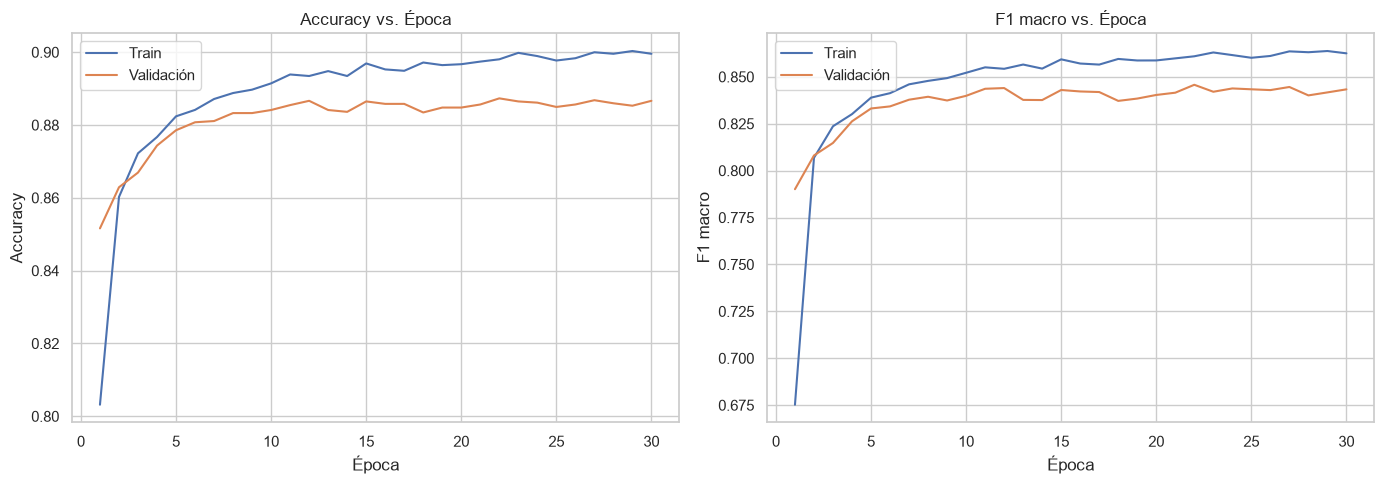

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS + 1), history["train_acc"], label="Train", color="#4C72B0")
axes[0].plot(range(1, EPOCHS + 1), history["val_acc"], label="Validación", color="#DD8452")
axes[0].set_title("Accuracy vs. Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(range(1, EPOCHS + 1), history["train_f1"], label="Train", color="#4C72B0")
axes[1].plot(range(1, EPOCHS + 1), history["val_f1"], label="Validación", color="#DD8452")
axes[1].set_title("F1 macro vs. Época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 macro")
axes[1].legend()

plt.tight_layout()
plt.show()


**Lectura de las curvas:** si `train_acc`/`train_f1` siguen subiendo mientras `val_acc`/`val_f1` se estancan o empeoran, es señal de sobreajuste (para lo cual ya se incluyó `Dropout(0.3)` como mitigación). Si ambas curvas convergen y se mantienen cercanas, el modelo generaliza razonablemente bien.

## 6. Classification report (set de validación)

In [108]:
model.eval()
all_logits, all_targets = [], []
with torch.no_grad():
    for xc, xcont, yb in val_loader:
        xc, xcont = xc.to(device), xcont.to(device)
        all_logits.append(model(xc, xcont).cpu())
        all_targets.append(yb)

val_logits = torch.cat(all_logits)
val_targets = torch.cat(all_targets).numpy().astype(int)
val_preds = (torch.sigmoid(val_logits) > 0.5).numpy().astype(int)

print(classification_report(val_targets, val_preds, target_names=["<=50K", ">50K"]))


              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.93      4445
        >50K       0.81      0.72      0.76      1492

    accuracy                           0.89      5937
   macro avg       0.86      0.83      0.84      5937
weighted avg       0.88      0.89      0.88      5937



## 7. Matriz de confusión — absoluta y normalizada por fila

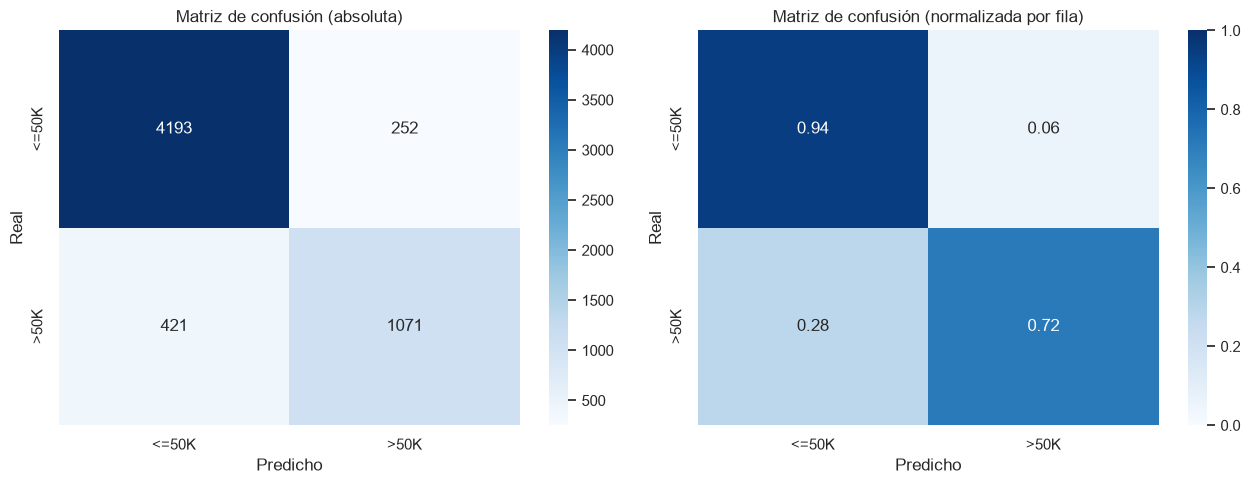

In [109]:
cm_abs = confusion_matrix(val_targets, val_preds)
cm_norm = confusion_matrix(val_targets, val_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["<=50K", ">50K"]

sns.heatmap(cm_abs, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=True)
axes[0].set_title("Matriz de confusión (absoluta)")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=True)
axes[1].set_title("Matriz de confusión (normalizada por fila)")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


**Conclusión:** el modelo con embeddings logra un buen desempeño general en el set de validación (accuracy y F1 macro cercanos a lo obtenido en la etapa exploratoria), sin necesidad de expandir `occupation`, `native-country` ni `skill-profile` en decenas de columnas one-hot. La matriz de confusión normalizada permite ver con claridad si el modelo comete más errores sobre la clase minoritaria (`>50K`), algo esperable dado el desbalance ~75/25 detectado en el EDA.

## 8. Aplicar las transformaciones al set de test

Se reutilizan **los mismos objetos ya ajustados con train** (`mapa_educacion`, `cols_onehot`, `occupation2idx`, `native_country2idx`, `skill_profile2idx`, `scaler`) — nunca se re-ajustan con el test, para no filtrar información.

Además, se contempla que el test puede tener **categorías no vistas en train** (ej. un país que no apareció en el set de entrenamiento). Para esos casos, se usa como *fallback* el índice de la categoría más frecuente de esa variable en train, evitando que el embedding reciba un índice inválido.

In [110]:
TEST_PATH = "adult_val.csv"

test_df = pd.read_csv(TEST_PATH)

# Elimina filas de test que son idénticas a alguna fila de train (evita leakage)
test_df = test_df.merge(train_df.drop_duplicates(), how="left", indicator=True)
test_df = test_df[test_df["_merge"] == "left_only"].drop(columns="_merge").reset_index(drop=True)

print("Dimensiones test:", test_df.shape)

test_enc = test_df.copy()
test_enc["sex"] = test_enc["sex"].map({"Male": 0, "Female": 1})
test_enc["income"] = test_enc["income"].map({"<=50K": 0, ">50K": 1})
test_enc["education_ordinal"] = test_enc["education"].map(mapa_educacion)

# One-Hot: se genera igual que en train y se alinean las columnas
# (por si el test no tiene alguna categoría, o tiene alguna de más)
test_enc = pd.get_dummies(test_enc, columns=cols_onehot, prefix=cols_onehot)
test_enc = test_enc.reindex(columns=df_enc.columns, fill_value=0)

# Embeddings: mapeo con los diccionarios de train + fallback para categorías nuevas
fallback_occ = occupation2idx[train_df["occupation"].mode()[0]]
fallback_country = native_country2idx[train_df["native-country"].mode()[0]]
fallback_skill = skill_profile2idx[train_df["skill-profile"].mode()[0]]

test_enc["occupation_idx"] = test_df["occupation"].map(occupation2idx).fillna(fallback_occ).astype(int)
test_enc["native-country_idx"] = test_df["native-country"].map(native_country2idx).fillna(fallback_country).astype(int)
test_enc["skill-profile_idx"] = test_df["skill-profile"].map(skill_profile2idx).fillna(fallback_skill).astype(int)

n_unseen = {
    "occupation": (test_df["occupation"].map(occupation2idx).isna()).sum(),
    "native-country": (test_df["native-country"].map(native_country2idx).isna()).sum(),
    "skill-profile": (test_df["skill-profile"].map(skill_profile2idx).isna()).sum(),
}
print("Categorías no vistas en train (reemplazadas por fallback):", n_unseen)


Dimensiones test: (14655, 14)
Categorías no vistas en train (reemplazadas por fallback): {'occupation': np.int64(0), 'native-country': np.int64(0), 'skill-profile': np.int64(0)}


In [111]:
# Arreglo final de features de test, en el mismo formato que espera el modelo
X_cat_test = test_enc[emb_cols].values.astype(np.int64)
X_cont_test = test_enc[cont_cols].values.astype(np.float32)

# Escalado con el scaler ya ajustado en train (no se re-ajusta)
X_cont_test[:, [cont_cols.index(c) for c in numeric_cols]] = scaler.transform(
    test_enc[numeric_cols].values.astype(np.float32)
)
y_test = test_enc["income"].values.astype(np.float32)

test_ds = AdultDataset(X_cat_test, X_cont_test, y_test)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)

print("X_cat_test:", X_cat_test.shape, "| X_cont_test:", X_cont_test.shape)


X_cat_test: (14655, 3) | X_cont_test: (14655, 31)


## 9. Evaluación final sobre el set de test

In [112]:
model.eval()
all_logits, all_targets = [], []
with torch.no_grad():
    for xc, xcont, yb in test_loader:
        xc, xcont = xc.to(device), xcont.to(device)
        all_logits.append(model(xc, xcont).cpu())
        all_targets.append(yb)

test_logits = torch.cat(all_logits)
test_targets = torch.cat(all_targets).numpy().astype(int)
test_preds = (torch.sigmoid(test_logits) > 0.5).numpy().astype(int)

print(classification_report(test_targets, test_preds, target_names=["<=50K", ">50K"]))


              precision    recall  f1-score   support

       <=50K       0.91      0.95      0.93     11003
        >50K       0.82      0.71      0.76      3652

    accuracy                           0.89     14655
   macro avg       0.86      0.83      0.84     14655
weighted avg       0.89      0.89      0.89     14655



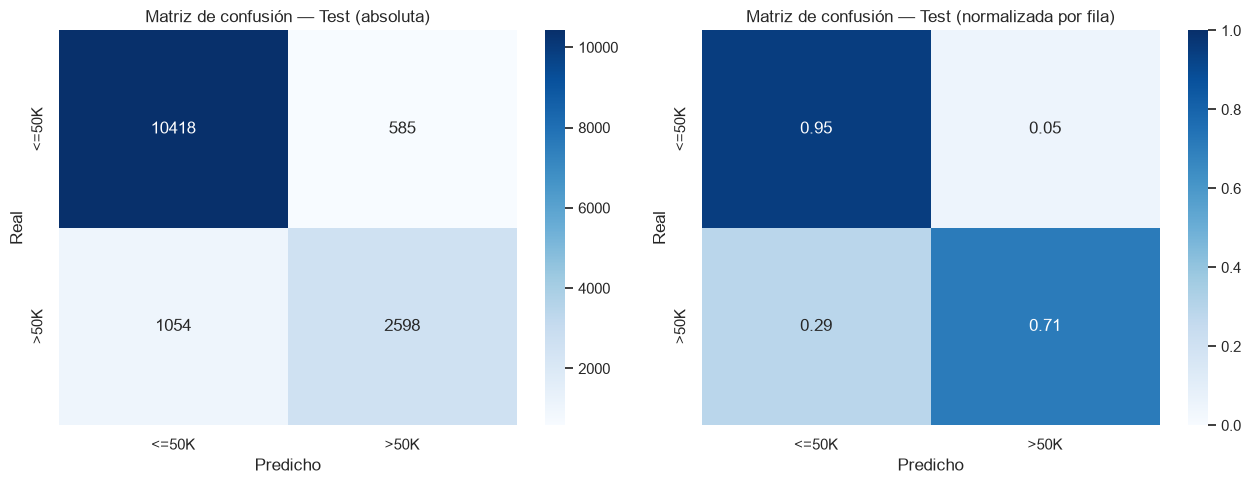

In [113]:
cm_abs = confusion_matrix(test_targets, test_preds)
cm_norm = confusion_matrix(test_targets, test_preds, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["<=50K", ">50K"]

sns.heatmap(cm_abs, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Matriz de confusión — Test (absoluta)")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Matriz de confusión — Test (normalizada por fila)")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


# c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

In [114]:
# One-Hot de las 3 variables que en el modelo b) iban por embedding.
# Se parte de df_enc (que ya tiene el one-hot de race/relationship/workclass/marital-status
# y las columnas de texto originales de occupation/native-country/skill-profile intactas).
cols_onehot_extra = ["occupation", "native-country", "skill-profile"]
df_enc_ohe = pd.get_dummies(df_enc, columns=cols_onehot_extra, prefix=cols_onehot_extra)

onehot_cols_extra = [c for c in df_enc_ohe.columns
                      if c.startswith(("occupation_", "native-country_", "skill-profile_"))]

# Set de features totalmente numérico/binario: numéricas + one-hot (b) + one-hot (nuevo)
cont_cols_c = numeric_cols + onehot_cols + onehot_cols_extra
print("N° de features de entrada (modelo c, todo one-hot):", len(cont_cols_c))
print("N° de features de entrada (modelo b, con embeddings):", len(emb_dims) + len(cont_cols))

df_enc_ohe.head()

N° de features de entrada (modelo c, todo one-hot): 169
N° de features de entrada (modelo b, con embeddings): 34


,age,education,sex,capital-gain,capital-loss,hours-per-week,income,education_ordinal,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,relationship_Husband,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,marital-status_Divorced,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_idx,native-country_idx,skill-profile_idx,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,native-country_Cambodia,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,skill-profile_accounting_bookkeeping,skill-profile_accounting_payroll,skill-profile_admin_document_control,skill-profile_admin_procurement_support,skill-profile_agriculture_field_work,skill-profile_automotive_repair,skill-profile_business_reporting_basic,skill-profile_caregiving_home_support,skill-profile_community_program_coordination,skill-profile_consulting_process_improvement,skill-profile_customer_service_hospitality,skill-profile_customer_service_retail,skill-profile_customer_success_operations,skill-profile_delivery_local_routes,skill-profile_education_classroom_teaching,skill-profile_education_curriculum_design,skill-profile_education_research_methods,skill-profile_education_teaching_assistant,skill-profile_engineering_drafting,skill-profile_engineering_quality_assurance,skill-profile_engineering_systems_design,skill-profile_entrepreneurship_business_development,skill-profile_entrepreneurship_small_business,skill-profile_executive_decision_support,skill-profile_facilities_maintenance,skill-profile_finance_budget_tracking,skill-profile_finance_financial_analysis,skill-profile_finance_investment_analysis,skill-profile_finance_risk_assessment,skill-profile_food_service_kitchen_basic,skill-profile_healthcare_clinical_coordination,skill-profile_healthcare_medical_assistant,skill-profile_healthcare_patient_support,skill-profile_healthcare_records_compliance,skill-profile_legal_case_management,skill-profile_legal_office_support,skill-profile_logistics_dispatch_coordination,skill-profile_logistics_forklift_operation,skill-profile_logistics_warehouse_basic,skill-profile_maintenance_janitorial,skill-profile_management_operations,skill-profile_management_people_operations,skill-profile_management_project_coordination,skill-profile_management_strategic_planning,skill-profile_management_team_lead,skill-profile_manufacturing_assembly,skill-profile_manufacturing_quality_control,skill-profile_office_data_entry_b

In [115]:
X_c = df_enc_ohe[cont_cols_c].values.astype(np.float32)
y_c = df_enc_ohe["income"].values.astype(np.float32)

# Mismo random_state y estratificación que en el modelo b) -> mismo split de filas,
# para que la comparación entre modelos sea justa (mismos ejemplos de train/val).
Xc_tr, Xc_val, yc_tr, yc_val = train_test_split(
    X_c, y_c, test_size=0.2, random_state=SEED, stratify=y_c
)

# Estandarización de las numéricas puras, ajustada solo con train (mismo criterio que en b)
scaler_c = StandardScaler()
scale_idx_c = [cont_cols_c.index(c) for c in numeric_cols]
Xc_tr[:, scale_idx_c] = scaler_c.fit_transform(Xc_tr[:, scale_idx_c])
Xc_val[:, scale_idx_c] = scaler_c.transform(Xc_val[:, scale_idx_c])

print("Train:", Xc_tr.shape, "-> balance:", yc_tr.mean().round(3))
print("Val:  ", Xc_val.shape, "-> balance:", yc_val.mean().round(3))

Train: (23746, 169) -> balance: 0.251
Val:   (5937, 169) -> balance: 0.251


In [116]:
class TabularOneHotDataset(Dataset):
    """Dataset sin variables de embedding: todo entra como un único vector continuo."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds_c = TabularOneHotDataset(Xc_tr, yc_tr)
val_ds_c = TabularOneHotDataset(Xc_val, yc_val)
train_loader_c = DataLoader(train_ds_c, batch_size=BATCH_SIZE, shuffle=True)
val_loader_c = DataLoader(val_ds_c, batch_size=512, shuffle=False)

In [117]:
class TabularNoEmbeddingNet(nn.Module):
    """Misma arquitectura que TabularEmbeddingNet (2 capas ocultas 128->64, ReLU),
    pero sin capas de embedding (todo llega ya como vector continuo/one-hot)
    y SIN Dropout (sin regularización interna)."""

    def __init__(self, n_input, hidden=(128, 64)):
        super().__init__()
        layers = []
        prev = n_input
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]  # sin nn.Dropout(...)
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x).squeeze(1)


model_c = TabularNoEmbeddingNet(n_input=len(cont_cols_c), hidden=(128, 64)).to(device)
model_c

TabularNoEmbeddingNet(
  (mlp): Sequential(
    (0): Linear(in_features=169, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [118]:
optimizer_c = torch.optim.Adam(model_c.parameters(), lr=1e-3)
criterion_c = nn.BCEWithLogitsLoss()  # misma justificación que en el modelo b): clasif. binaria
EPOCHS_C = 30


def run_epoch_c(loader, train=True):
    model_c.train() if train else model_c.eval()
    total_loss, all_preds, all_targets = 0.0, [], []

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            if train:
                optimizer_c.zero_grad()
            logits = model_c(xb)
            loss = criterion_c(logits, yb)
            if train:
                loss.backward()
                optimizer_c.step()

            total_loss += loss.item() * len(yb)
            preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1m = f1_score(all_targets, all_preds, average="macro")
    return avg_loss, acc, f1m


history_c = {"train_acc": [], "val_acc": [], "train_f1": [], "val_f1": [],
             "train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS_C + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch_c(train_loader_c, train=True)
    val_loss, val_acc, val_f1 = run_epoch_c(val_loader_c, train=False)

    history_c["train_loss"].append(tr_loss)
    history_c["val_loss"].append(val_loss)
    history_c["train_acc"].append(tr_acc)
    history_c["val_acc"].append(val_acc)
    history_c["train_f1"].append(tr_f1)
    history_c["val_f1"].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:2d}/{EPOCHS_C} | "
              f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={tr_acc:.4f} val_acc={val_acc:.4f} | "
              f"train_f1={tr_f1:.4f} val_f1={val_f1:.4f}")

Epoch  1/30 | train_loss=0.4299 val_loss=0.3166 | train_acc=0.7972 val_acc=0.8550 | train_f1=0.6468 val_f1=0.8047
Epoch  5/30 | train_loss=0.2637 val_loss=0.2739 | train_acc=0.8875 val_acc=0.8819 | train_f1=0.8458 val_f1=0.8331
Epoch 10/30 | train_loss=0.2541 val_loss=0.2689 | train_acc=0.8920 val_acc=0.8818 | train_f1=0.8528 val_f1=0.8364
Epoch 15/30 | train_loss=0.2541 val_loss=0.2745 | train_acc=0.8914 val_acc=0.8826 | train_f1=0.8518 val_f1=0.8312
Epoch 20/30 | train_loss=0.2455 val_loss=0.2656 | train_acc=0.8951 val_acc=0.8828 | train_f1=0.8568 val_f1=0.8391
Epoch 25/30 | train_loss=0.2416 val_loss=0.2684 | train_acc=0.8954 val_acc=0.8848 | train_f1=0.8577 val_f1=0.8428
Epoch 30/30 | train_loss=0.2354 val_loss=0.2762 | train_acc=0.9002 val_acc=0.8831 | train_f1=0.8640 val_f1=0.8362


## Curvas de accuracy y F1 macro vs. época (Modelo sin embeddings)

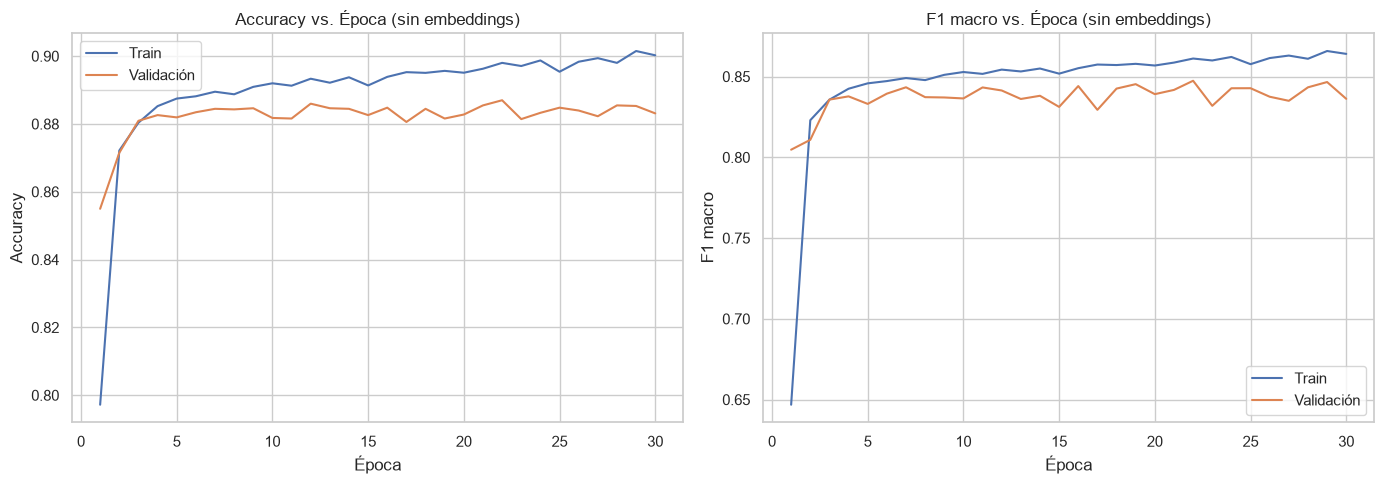

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, EPOCHS_C + 1), history_c["train_acc"], label="Train", color="#4C72B0")
axes[0].plot(range(1, EPOCHS_C + 1), history_c["val_acc"], label="Validación", color="#DD8452")
axes[0].set_title("Accuracy vs. Época (sin embeddings)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(range(1, EPOCHS_C + 1), history_c["train_f1"], label="Train", color="#4C72B0")
axes[1].plot(range(1, EPOCHS_C + 1), history_c["val_f1"], label="Validación", color="#DD8452")
axes[1].set_title("F1 macro vs. Época (sin embeddings)")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("F1 macro"); axes[1].legend()

plt.tight_layout()
plt.show()

## Classification report (Modelo sin embeddings)

In [120]:
model_c.eval()
all_logits_c, all_targets_c = [], []
with torch.no_grad():
    for xb, yb in val_loader_c:
        xb = xb.to(device)
        all_logits_c.append(model_c(xb).cpu())
        all_targets_c.append(yb)

val_logits_c = torch.cat(all_logits_c)
val_targets_c = torch.cat(all_targets_c).numpy().astype(int)
val_preds_c = (torch.sigmoid(val_logits_c) > 0.5).numpy().astype(int)

print(classification_report(val_targets_c, val_preds_c, target_names=["<=50K", ">50K"]))

              precision    recall  f1-score   support

       <=50K       0.90      0.95      0.92      4445
        >50K       0.81      0.69      0.75      1492

    accuracy                           0.88      5937
   macro avg       0.86      0.82      0.84      5937
weighted avg       0.88      0.88      0.88      5937



## Matriz de confusión (Modelo sin embeddings)

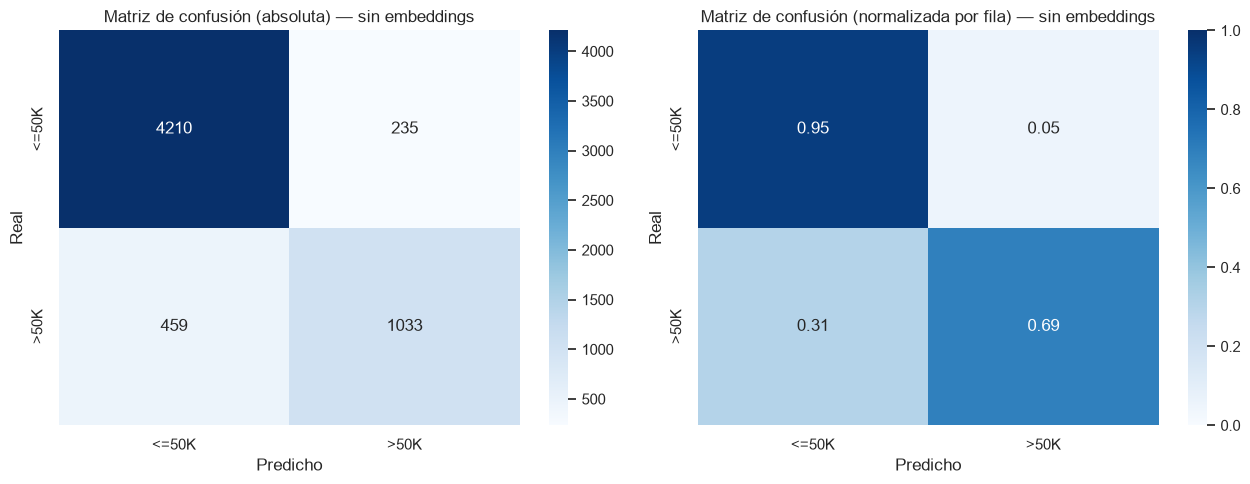

In [121]:
cm_abs_c = confusion_matrix(val_targets_c, val_preds_c)
cm_norm_c = confusion_matrix(val_targets_c, val_preds_c, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["<=50K", ">50K"]

sns.heatmap(cm_abs_c, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Matriz de confusión (absoluta) — sin embeddings")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

sns.heatmap(cm_norm_c, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Matriz de confusión (normalizada por fila) — sin embeddings")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


## Evaluación sobre el set de test externo (`adult_val.csv`)  Modelo sin embeddings

Se reutiliza `test_df` ya cargado en la sección b), aplicando el mismo criterio: one-hot alineado a las columnas de train (`reindex`) y `scaler_c` (ajustado solo con train) para las numéricas.

In [122]:
test_enc_c = test_df.copy()
test_enc_c["sex"] = test_enc_c["sex"].map({"Male": 0, "Female": 1})
test_enc_c["income"] = test_enc_c["income"].map({"<=50K": 0, ">50K": 1})
test_enc_c["education_ordinal"] = test_enc_c["education"].map(mapa_educacion)

cols_onehot_all = cols_onehot + cols_onehot_extra  # las 4 de siempre + las 3 nuevas
test_enc_c = pd.get_dummies(test_enc_c, columns=cols_onehot_all, prefix=cols_onehot_all)
test_enc_c = test_enc_c.reindex(columns=df_enc_ohe.columns, fill_value=0)

X_test_c = test_enc_c[cont_cols_c].values.astype(np.float32)
X_test_c[:, scale_idx_c] = scaler_c.transform(test_enc_c[numeric_cols].values.astype(np.float32))
y_test_c = test_enc_c["income"].values.astype(np.float32)

test_ds_c = TabularOneHotDataset(X_test_c, y_test_c)
test_loader_c = DataLoader(test_ds_c, batch_size=512, shuffle=False)

model_c.eval()
all_logits_tc, all_targets_tc = [], []
with torch.no_grad():
    for xb, yb in test_loader_c:
        xb = xb.to(device)
        all_logits_tc.append(model_c(xb).cpu())
        all_targets_tc.append(yb)

test_logits_c = torch.cat(all_logits_tc)
test_targets_c = torch.cat(all_targets_tc).numpy().astype(int)
test_preds_c = (torch.sigmoid(test_logits_c) > 0.5).numpy().astype(int)

print(classification_report(test_targets_c, test_preds_c, target_names=["<=50K", ">50K"]))


              precision    recall  f1-score   support

       <=50K       0.84      0.98      0.90     11003
        >50K       0.87      0.43      0.58      3652

    accuracy                           0.84     14655
   macro avg       0.85      0.70      0.74     14655
weighted avg       0.85      0.84      0.82     14655



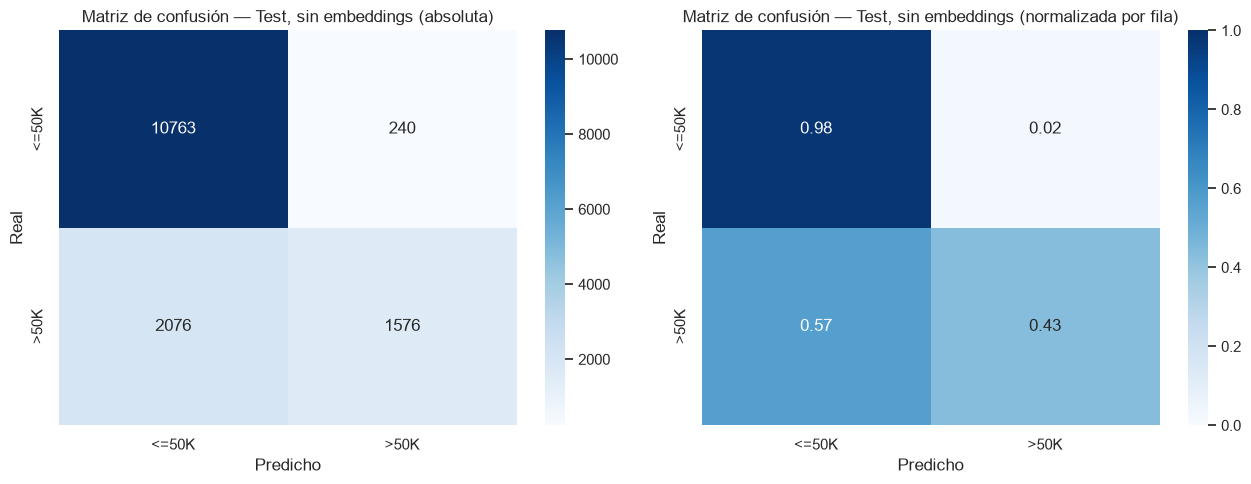

In [123]:
cm_abs_tc = confusion_matrix(test_targets_c, test_preds_c)
cm_norm_tc = confusion_matrix(test_targets_c, test_preds_c, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_abs_tc, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title("Matriz de confusión — Test, sin embeddings (absoluta)")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

sns.heatmap(cm_norm_tc, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title("Matriz de confusión — Test, sin embeddings (normalizada por fila)")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


## d) Conclusiones finales

In [125]:
def count_params(module):
    return sum(p.numel() for p in module.parameters())

# --- Modelo b) con embeddings ---
emb_params_b = sum(count_params(e) for e in model.embeddings)
mlp_params_b = count_params(model.mlp)
total_params_b = count_params(model)
input_dim_b = sum(emb_dims) + len(cont_cols)

# --- Modelo c) sin embeddings (one-hot) ---
mlp_params_c = count_params(model_c.mlp)
total_params_c = count_params(model_c)
input_dim_c = len(cont_cols_c)

resumen = pd.DataFrame({
    "Dimensión de entrada": [input_dim_b, input_dim_c],
    "Parámetros capa de entrada (embeddings/one-hot)": [emb_params_b, 0],
    "Parámetros del resto de la red (MLP)": [mlp_params_b, mlp_params_c],
    "Parámetros totales": [total_params_b, total_params_c],
}, index=["Modelo b) con embeddings", "Modelo c) sin embeddings"])

resumen

,Dimensión de entrada,Parámetros capa de entrada (embeddings/one-hot),Parámetros del resto de la red (MLP),Parámetros totales
Modelo b) con embeddings,45,778,14209,14987
Modelo c) sin embeddings,169,0,30081,30081



### Tabla comparativa

| Aspecto | Modelo b) Con embeddings | Modelo c) Sin embeddings (One-Hot) |
|---|---|---|
| Codificación de `occupation`, `native-country`, `skill-profile` | Embeddings (dim 4, 2, 8) | One-Hot |
| Dropout | Sí (0.3 en cada capa oculta) | No |
| Dimensión de entrada a la red | **45** | **169** |
| Parámetros en la capa de entrada (embeddings vs. one-hot) | 778 (embeddings) | 0 (one-hot no agrega parámetros propios) |
| Parámetros totales del modelo | **14,987** | **30,081** |
| Accuracy - validación interna (época 30) | 0.8866 | 0.8831 |
| F1 macro - validación interna (época 30) | 0.8433 | 0.8362 |
| Accuracy - test externo (`adult_val.csv`) | **0.89** | **0.84** |
| F1 macro - test externo (`adult_val.csv`) | **0.84** | **0.74** |
| Recall clase `>50K` — test externo | 0.71 | **0.43** |

### Observaciones

- **Tamaño del modelo:** el modelo sin embeddings tiene **más del doble de parámetros** (30,081 vs. 14,987) a pesar de compartir la misma cantidad de capas ocultas, simplemente porque la capa de entrada debe absorber 169 features one-hot en lugar de 45 valores. Los embeddings comprimen información de 135 categorías (14+41+80) en solo 14 números por fila.

- **Riesgo de la alta dimensionalidad:** con 169 columnas de entrada, la mayoría binarias y dispersas, el espacio de combinaciones posibles entre categorías crece exponencialmente. El modelo sin dropout tiene libertad para ajustar pesos a combinaciones específicas de esas 169 columnas presentes en el 80% de train, en lugar de aprender un patrón general. Esto es exactamente la maldición de la dimensionalidad aplicada a una red totalmente conectada: cuantas más columnas dispersas, más fácil es memorizar en vez de generalizar, sobre todo sin ningún mecanismo de regularización que lo evite.

- **Por qué la matriz de confusión cambia tanto entre validación interna y test externo (solo en el modelo sin embeddings):** la validación interna (20%) proviene del mismo archivo que el train, por lo que comparte muchas combinaciones exactas de categorías ya vistas. El test externo (`adult_val.csv`), en cambio, aunque no tiene categorías nuevas de forma individual, sí presenta combinaciones conjuntas de esas 169 columnas que el modelo no vio. Sin dropout que limite la dependencia en neuronas/combinaciones puntuales, esas combinaciones nuevas pueden "desorientarlo", ya que el modelo no esta regularizado, y esto golpea particularmente a la clase minoritaria (`>50K`), cuyo recall cae de 0.69 (validación interna) a 0.43 (test externo). El modelo con embeddings, al aprender una representación densa y compartida entre categorías en lugar de depender de columnas dispersas puntuales, no sufre esta caída: su matriz de confusión se mantiene consistente entre ambos sets.

- **Desempeño en test externo (la comparación relevante):** el modelo con embeddings **mantiene** su desempeño (0.89 accuracy / 0.84 F1 macro), mientras que el modelo sin embeddings **cae notablemente** (0.84 / 0.74).

### Conclusión

Para variables categóricas de alta cardinalidad (`native-country`: 41, `skill-profile`: 80), los embeddings no solo son más eficientes en parámetros, sino que resultaron indispensables para que el modelo generalizara correctamente a datos no vistos, en particular para detectar la clase minoritaria (`>50K`). El one-hot, al expandir la dimensionalidad de entrada casi 4 veces y combinarse con la ausencia de dropout, produjo un modelo más propenso a memorizar combinaciones específicas del set de entrenamiento en lugar de aprender patrones generalizables, evidencia clara de que la elección de codificación categórica no es un detalle menor, sino una decisión de diseño con impacto directo en el desempeño final, especialmente al evaluar sobre datos genuinamente nuevos.